Продвинутая визуализация данных с помощью Seaborn

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [13]:
# Загрузка датасета “tips” из seaborn
tips = sns.load_dataset("tips")

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [14]:
# Вывод списка столбцов с типами данных
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


total_bill - сумма счета

tip - чаевые

sex - пол посетителя

smoker - курящие/не курящие

day - день посещения(день недели)

time - в какое время дня посетили

size - количество человек

# 1. В какой день недели посетители оставляют больше всего чаевых по отношению к сумме чека? 

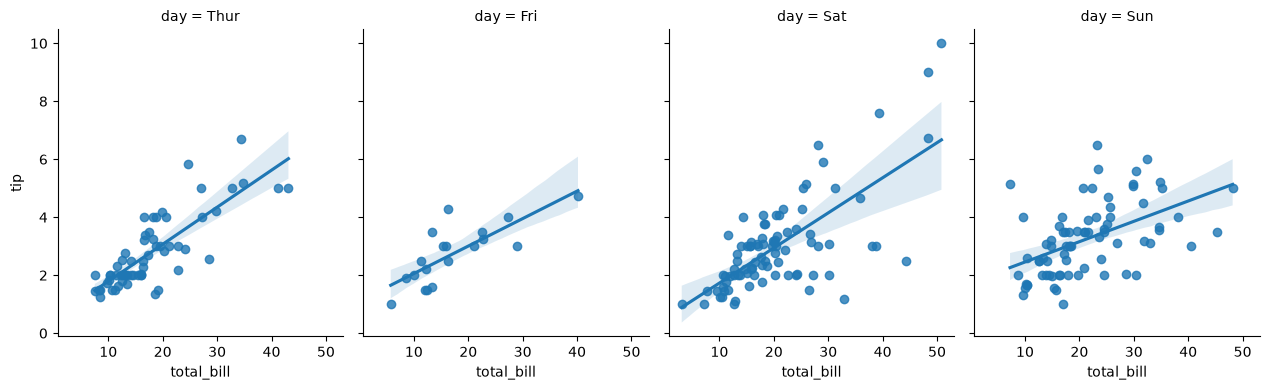

In [6]:
sns.lmplot(
    data=tips,
    x="total_bill",
    y="tip",
    col="day",
    # col_order=["Thur", "Fri", "Sat", "Sun"],
    height=4,
    aspect=0.8
)

# 2. Кто покупает на большую сумму (по дням) – курящие или некурящие?

Text(0, 0.5, 'total_bill')

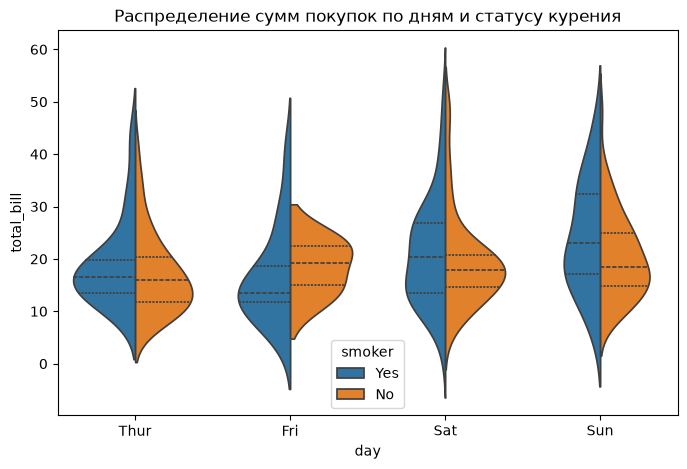

In [7]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="smoker",
    split=True,
    inner='quartile'
)

plt.title("Распределение сумм покупок по дням и статусу курения")
plt.xlabel("day")
plt.ylabel("total_bill")

# 3. В каком количестве чаще всего бывает компания + Правда ли то, что большие компании тратят в среднем больше (relplot)? 

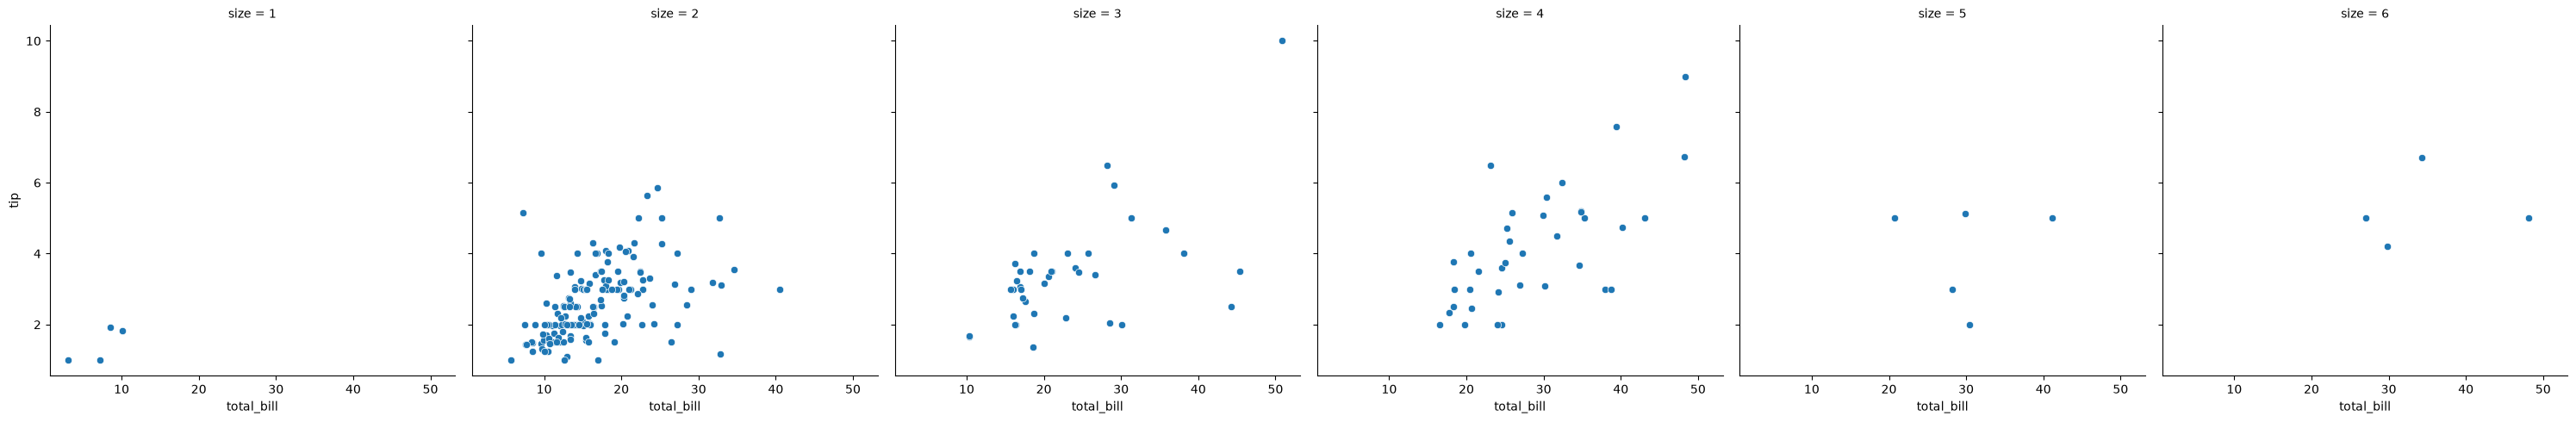

In [8]:
sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    col="size"
)

# 4. Создание нового признака «Процент чаевых». Как процент чаевых зависит от дня недели и пола?

Text(0.5, 1.0, 'Процент чаевых в зависимости от дня недели и пола')

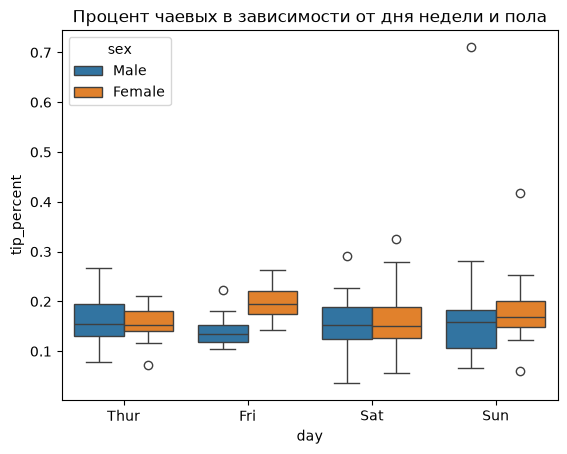

In [9]:
tips["tip_percent"] = tips["tip"] / tips["total_bill"]

sns.boxplot(
    data=tips,
    x="day",
    y="tip_percent",
    hue="sex"
)
plt.title("Процент чаевых в зависимости от дня недели и пола")

# 5. С помощью jointplot показана зависимость между размером группы посетителей и процентом чаевых.



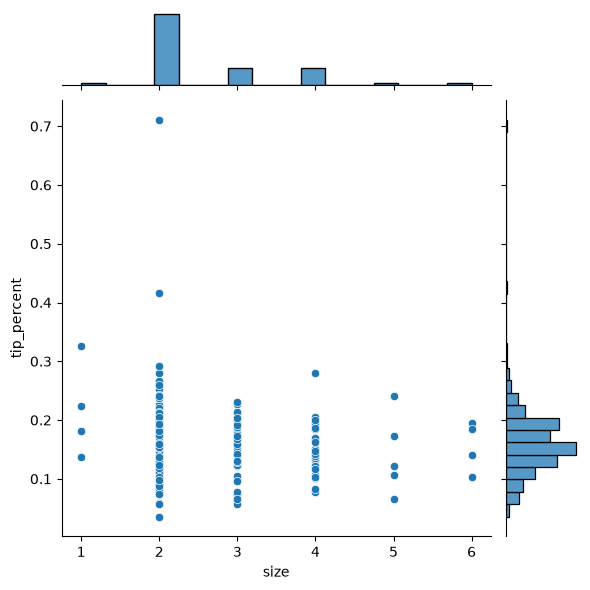

In [10]:
sns.jointplot(
    tips,
    x="size",
    y="tip_percent",
)

# 6. зависимость между общей суммой и размером чаевых с помощью jointplot kde (заполненный контур):

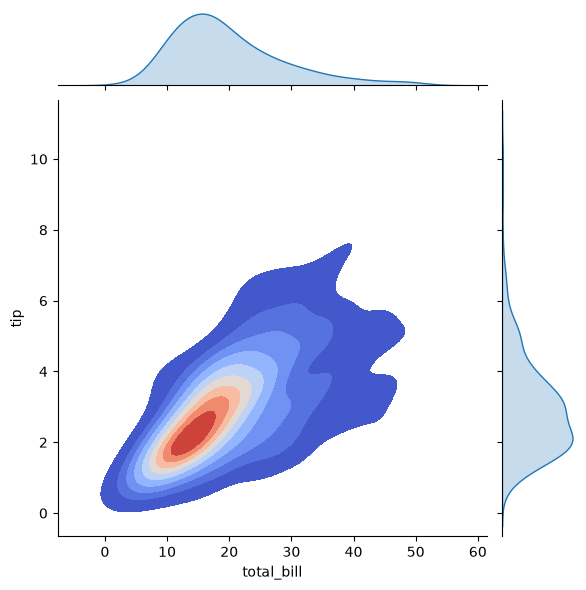

In [11]:
sns.jointplot(
    tips,
    x="total_bill",
    y="tip",
    kind="kde",
    fill=True,
    cmap="coolwarm"
)

# 7.  Превращение всех категорий в целые числа +pairplot, heatmap для корреляции.

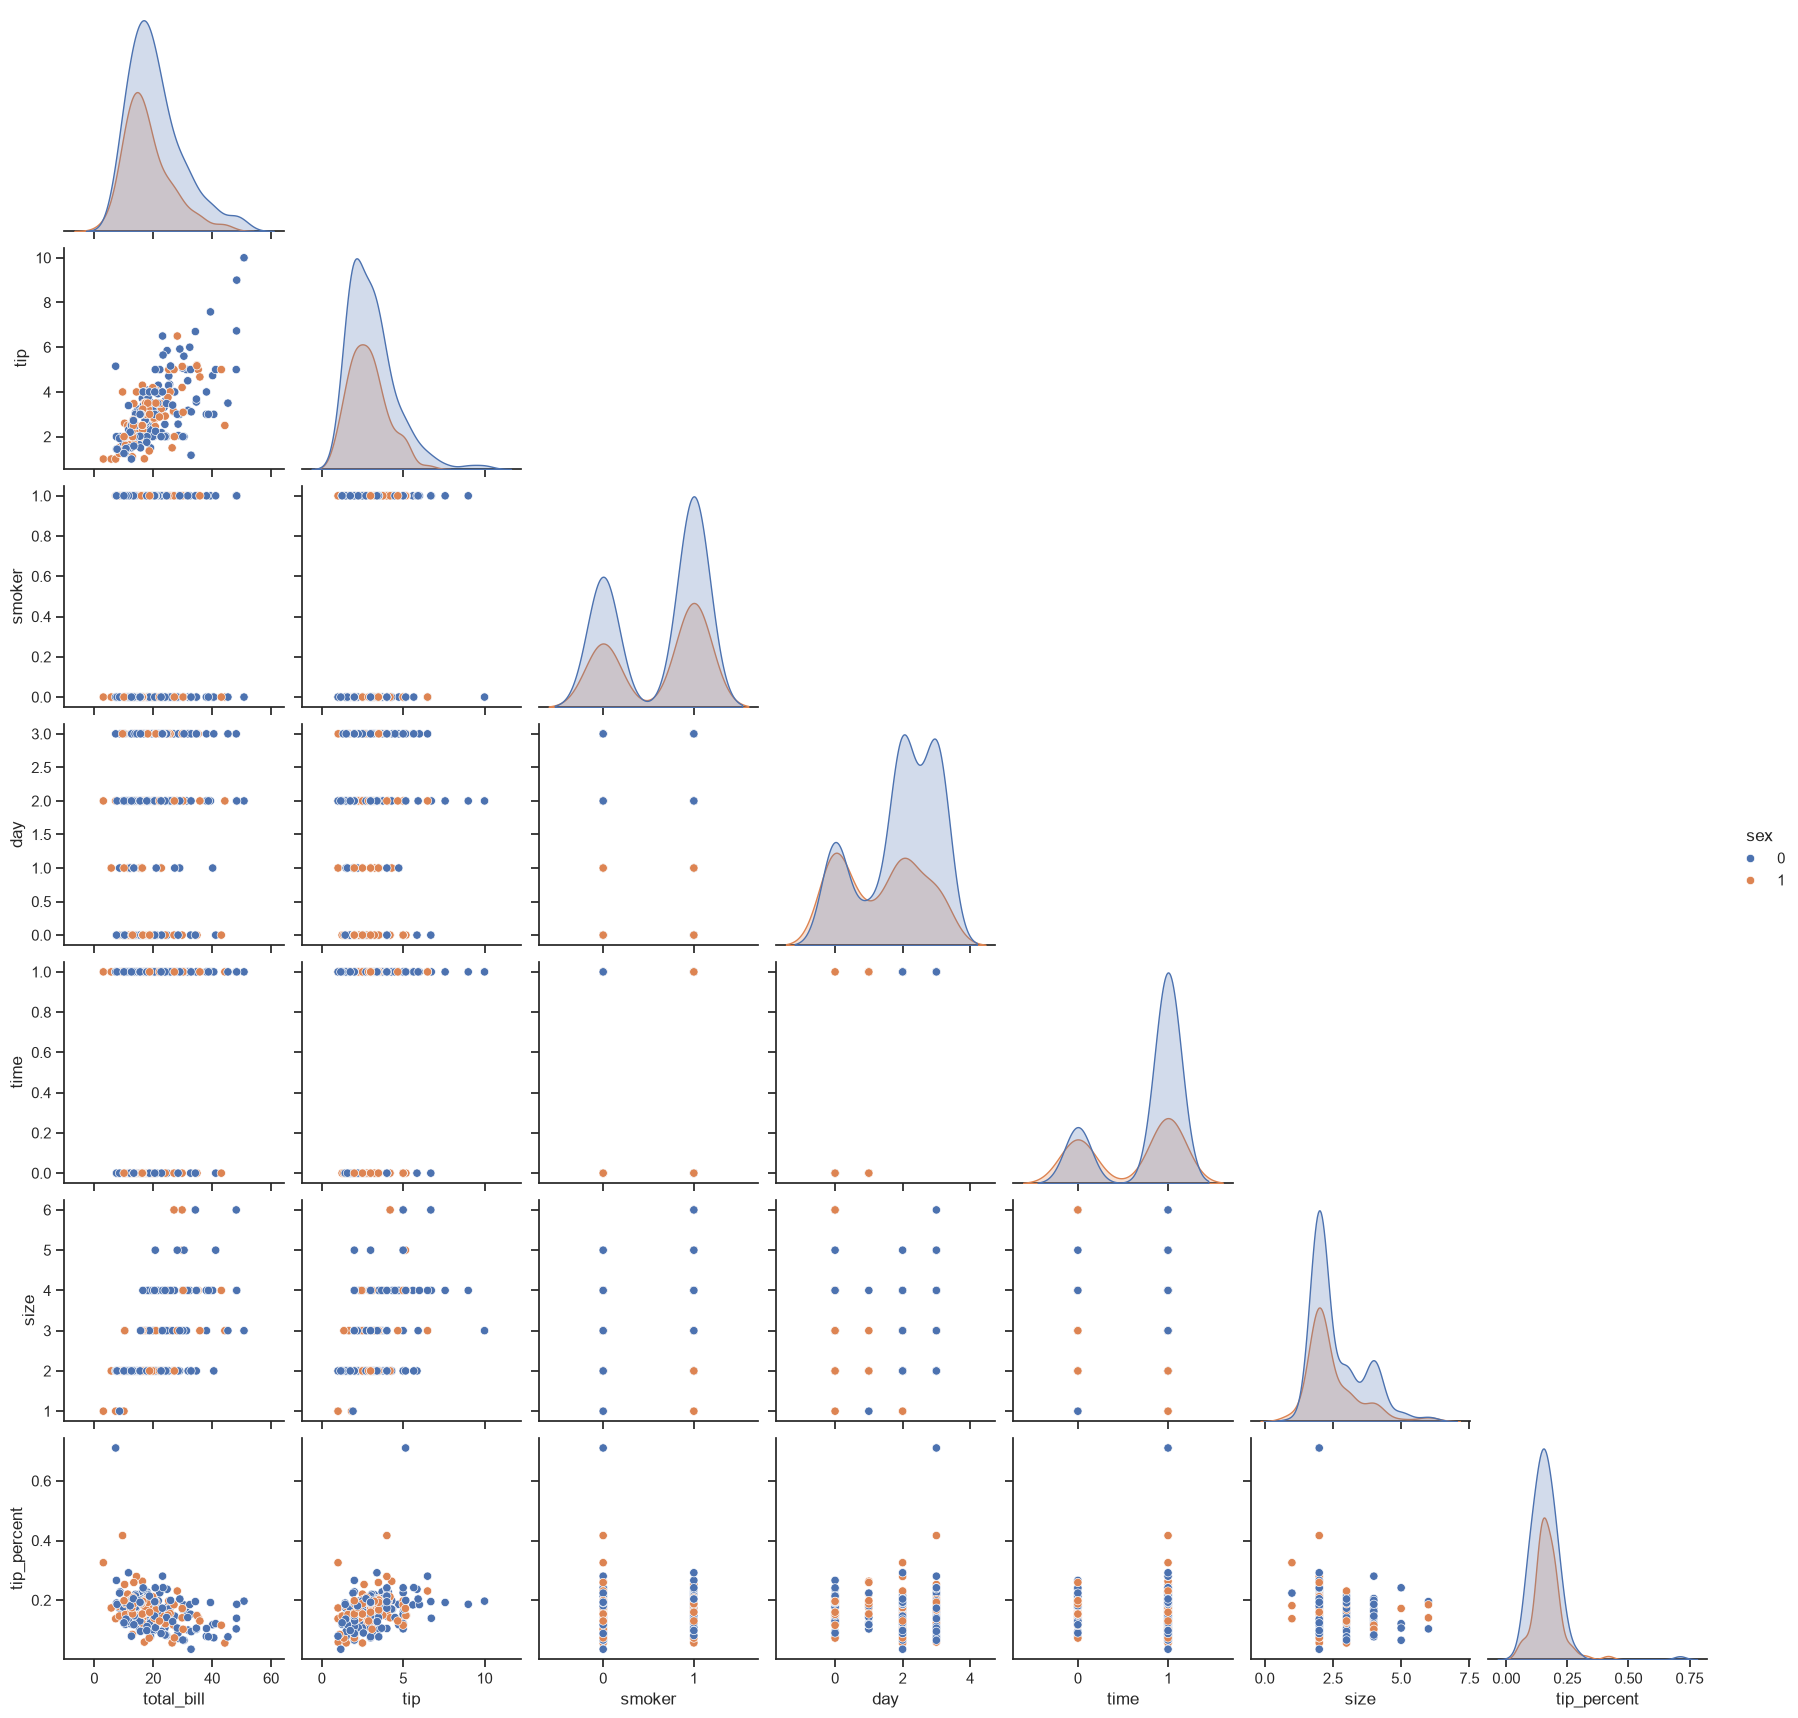

Text(0.5, 1.0, 'Тепловая карта корреляции признаков')

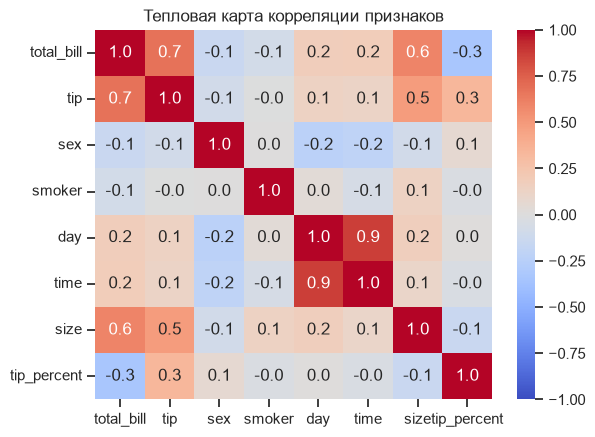

In [12]:
# Преобразуем все категориальные признаки в числовые коды
tips = tips.apply(lambda x: x.cat.codes if x.dtype.name == "category" else x)

# --- Pairplot ---
sns.set_theme(style="ticks", color_codes=True)
sns.pairplot(tips, hue='sex', corner=True)
plt.show()

# --- Тепловая карта корреляции ---
corr_matrix = tips.corr(numeric_only=True)
sns.heatmap(
    corr_matrix,
    vmax=1, vmin=-1,
    annot=True,
    fmt='.1f',
    cmap="coolwarm"
)
plt.title("Тепловая карта корреляции признаков", fontsize=12)


1. Процент чаевых (pct) чаще всего находится в диапазоне 10–20%.

2. Сумма счёта (total_bill) и размер чаевых (tip) имеют сильную положительную корреляцию (~0.7).

3. Процент чаевых (pct) слабо отрицательно связан с total_bill (около -0.3).

4. Пол, курение и время суток оказывают минимальное влияние на процент чаевых.